In [29]:
from bez.cnn.train import create_pattern_bank, gen_synthetic_images
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
from bez.cnn.model import Rasterizer
from bez.data import load_normalized
import torch

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


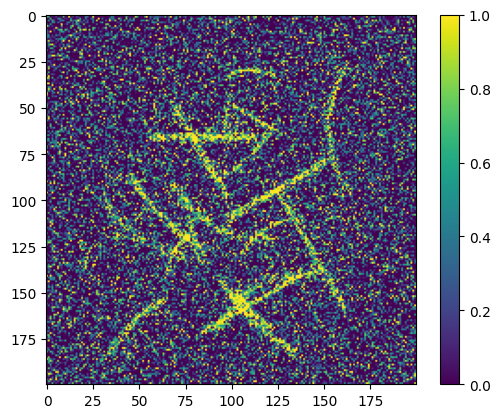

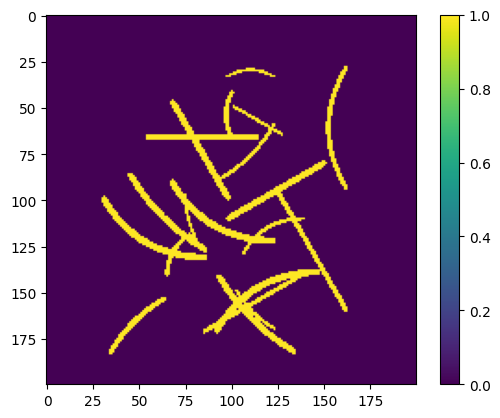

In [40]:
bank, bank_bin = create_pattern_bank([31, 45, 61, 75])
x, y = gen_synthetic_images(bank, bank_bin, 1, 200, 200, 20)
plt.imshow(x[0][0])
plt.colorbar()
plt.show()
plt.imshow(y[0][0])
plt.colorbar()
plt.show()

  0%|                                                                                                      | 0/100 [00:00<?, ?it/s]

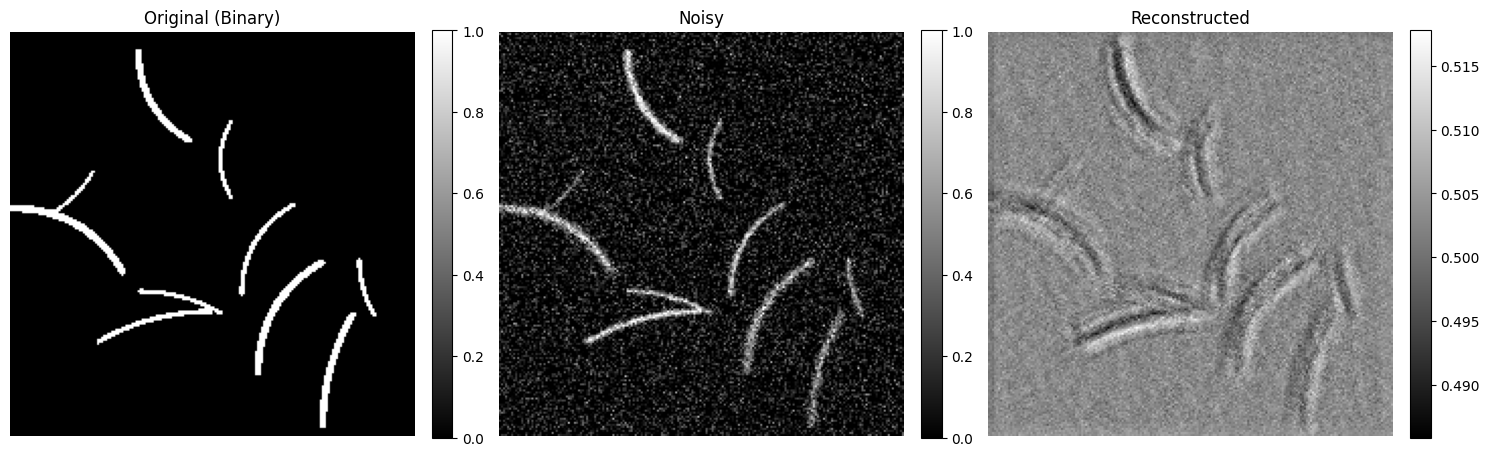

  5%|████▋                                                                                         | 5/100 [00:58<14:36,  9.22s/it]

In [ ]:
N_iter = 100
model = Rasterizer(32)
criterion = torch.nn.BCELoss()
opti = torch.optim.AdamW(model.parameters(), lr=1e-1)
losses = []

for step in trange(N_iter):
    # Generate synthetic data
    x, y = gen_synthetic_images(bank, bank_bin, 10, 200, 200, 10)
    
    # Training step
    opti.zero_grad()
    y_pred = model.forward(x)
    loss = criterion(y_pred, y)
    loss.backward()
    opti.step()
    
    # Display triplets every 30 steps
    if step % 10 == 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
                                                                                             # Original (binary)
         # Original (binary)
        im1 = axes[0].imshow(y[0][0].detach(), cmap='gray')
        axes[0].set_title('Original (Binary)')
        axes[0].axis('off')
        plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
        
        # Noisy
        im2 = axes[1].imshow(x[0][0].detach(), cmap='gray')
        axes[1].set_title('Noisy')
        axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        
        # Reconstructed
        im3 = axes[2].imshow(y_pred[0][0].detach(), cmap='gray')
        axes[2].set_title('Reconstructed')
        axes[2].axis('off')
        plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()
        
    losses.append(loss.detach())

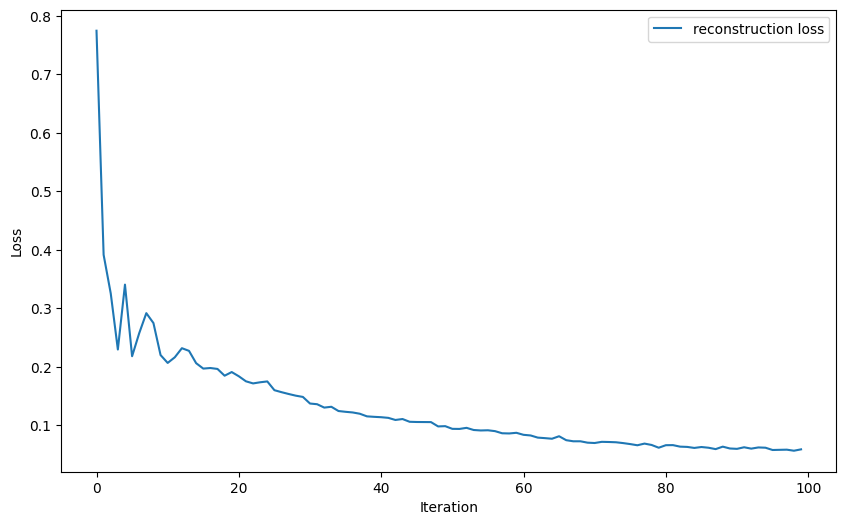

In [42]:
# Plot final loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="reconstruction loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

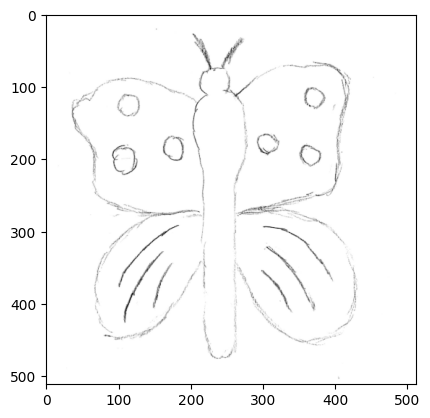

In [43]:
butterfly = load_normalized(ROOT_DIR / "data/sketches/butterfly.png")
plt.imshow(butterfly, cmap="binary")
plt.show()

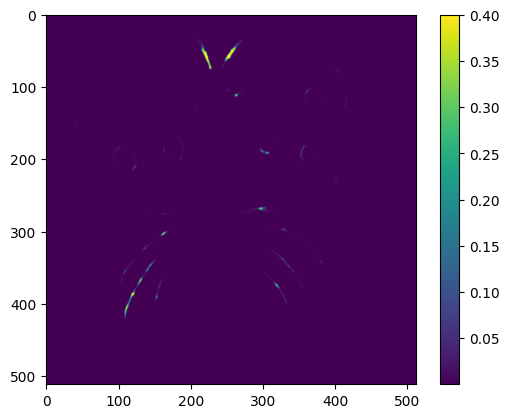

In [44]:
out = model.forward(torch.FloatTensor(butterfly).unsqueeze(0))[0].detach()
plt.imshow(out)
plt.colorbar()
plt.show()

In [8]:
from bez.cnn import load_trained_model
model = load_trained_model()

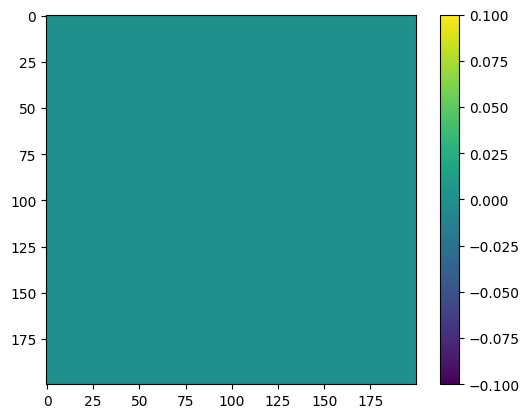

In [10]:
pred = model.run(["output"], {"input": y[0].numpy()})[0][0]
plt.imshow(pred)
plt.colorbar()

In [35]:
y[0].array()

AttributeError: 'Tensor' object has no attribute 'array'